In [1]:
%load_ext autoreload

In [2]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

%autoreload
import covid19_inference.covid19_inference as cov19
import utils
import plot
import model
import data_prep

In [9]:
all_indicator_combinations = utils.indicator_combinations(
    #["C", "R", "ICU", "H"]
    )

# Input

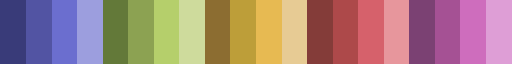

In [3]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['tab20b']
colormap

# Single

## Cases

In [25]:
# load trace from file
tag = "C_kurzarbeit"
indicators = ["C"]
C_trace = load_trace(tag)
#C_model = load_model(indicators, {'C': case_data})

In [56]:
# load trace from file
tag = "C_test_p_linear"
indicators = ["C"]
C_trace_linear = load_trace(tag)
C_model_linear = load_model(indicators, {'C': case_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [26]:
az.summary(C_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta_o,3.451,0.983,1.854,5.278,0.041,0.031,638.0,342.0,1.01
z_C,0.120,0.022,0.085,0.162,0.001,0.001,384.0,308.0,1.00
mu_C,0.928,0.278,0.466,1.410,0.011,0.008,605.0,317.0,1.01
delta_C,0.168,0.243,0.011,0.497,0.013,0.009,572.0,307.0,1.00
z_S,0.149,0.023,0.111,0.196,0.001,0.001,525.0,342.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.134,0.155,5.876,6.410,0.008,0.006,401.0,308.0,1.00
m[33],6.050,0.154,5.795,6.322,0.008,0.005,401.0,308.0,1.00
m[34],6.018,0.153,5.749,6.276,0.008,0.005,402.0,308.0,1.00
m[35],5.984,0.151,5.738,6.249,0.008,0.005,403.0,307.0,1.00


Sampling: [delta_o]
INFO     [pymc] Sampling: [delta_o]


Directory  figures/C_kurzarbeit  already exists.


Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_C]
INFO     [pymc] Sampling: [z_C]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [delta_C, mu_C]
INFO     [pymc] Sampling: [delta_C, mu_C]
Sampling: [delta_C]
INFO     [pymc] Sampling: [delta_C]


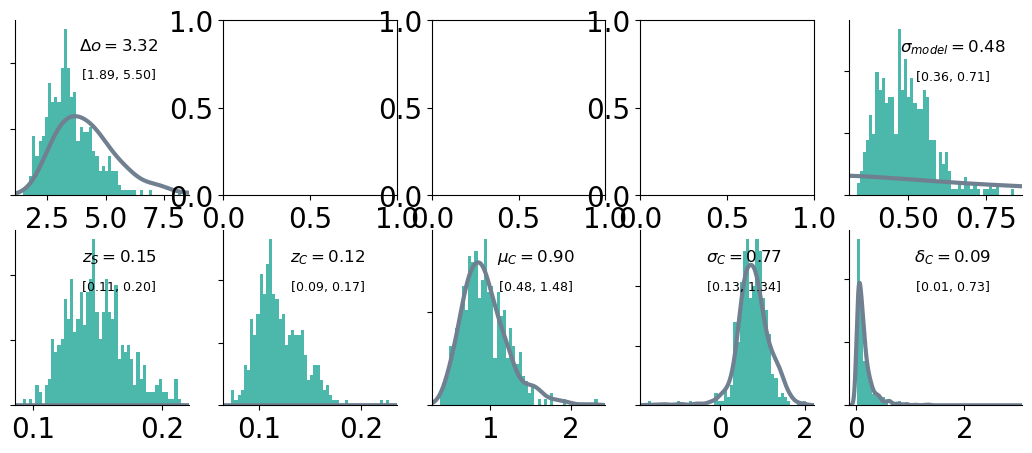

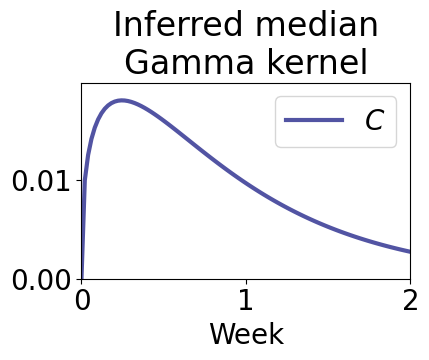

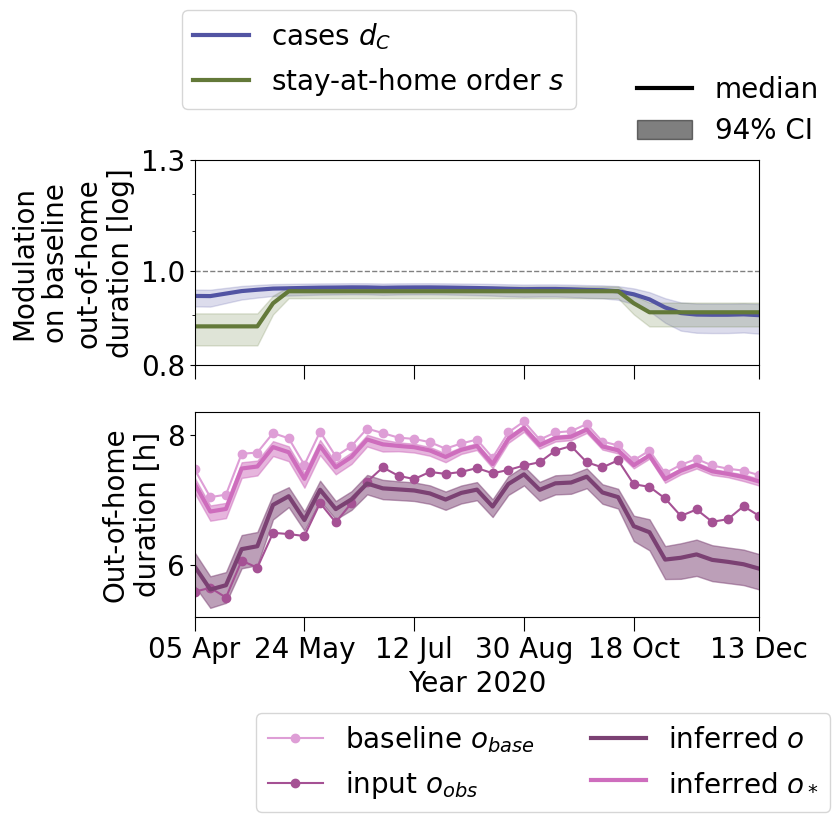

In [29]:
plot.analysis_figures(C_model, C_trace, tag, dates, indicators)

## R

In [5]:
tag = "test_sigmoid"
indicator = "R_"
# load trace from file
R_trace = utils.load_trace(tag, indicator)
# load model
#R_model = inference_model

In [11]:
az.summary(R_trace)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
delta_o,3.431,0.929,1.744,4.988,0.062,0.046,268.0,254.0,1.00
z_R,0.129,0.043,0.069,0.210,0.003,0.002,174.0,250.0,1.02
mu_R,1.045,0.358,0.493,1.658,0.017,0.012,440.0,299.0,1.01
sigma_R,1.102,0.356,0.500,1.691,0.020,0.015,288.0,247.0,1.02
z_S,0.266,0.079,0.150,0.399,0.007,0.005,168.0,164.0,1.01
...,...,...,...,...,...,...,...,...,...
m[32],6.030,0.340,5.412,6.508,0.032,0.023,137.0,232.0,1.01
m[33],6.047,0.315,5.477,6.488,0.030,0.021,137.0,231.0,1.01
m[34],6.054,0.305,5.504,6.475,0.029,0.021,136.0,231.0,1.01
m[35],6.050,0.296,5.520,6.460,0.029,0.020,136.0,218.0,1.01


Sampling: [delta_o]
INFO     [pymc.sampling.forward] Sampling: [delta_o]


Directory  figures/R_test  already exists.


Sampling: [z_S]
INFO     [pymc.sampling.forward] Sampling: [z_S]
Sampling: [z_school]
INFO     [pymc.sampling.forward] Sampling: [z_school]
Sampling: [sigma_model]
INFO     [pymc.sampling.forward] Sampling: [sigma_model]
Sampling: [z_R]
INFO     [pymc.sampling.forward] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc.sampling.forward] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc.sampling.forward] Sampling: [sigma_R]
/data/eiftekhar/mobility_inference/covid19_inference/covid19_inference/model/utility.py:169: RuntimeWarning: divide by zero encountered in power
  distr = beta**alpha * x ** (alpha - 1) * at.exp(-beta * x)


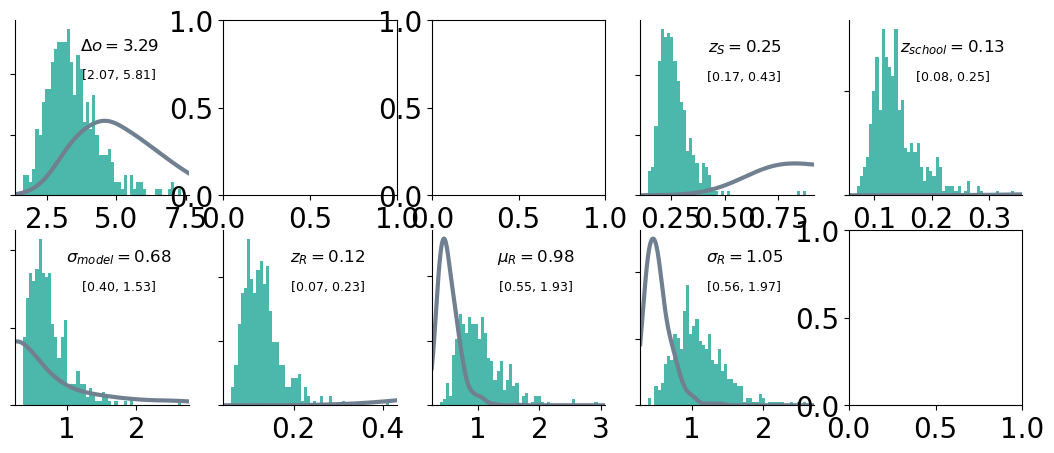

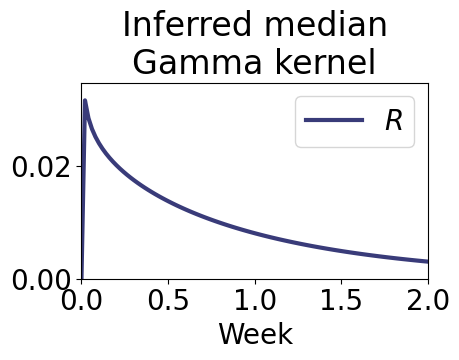

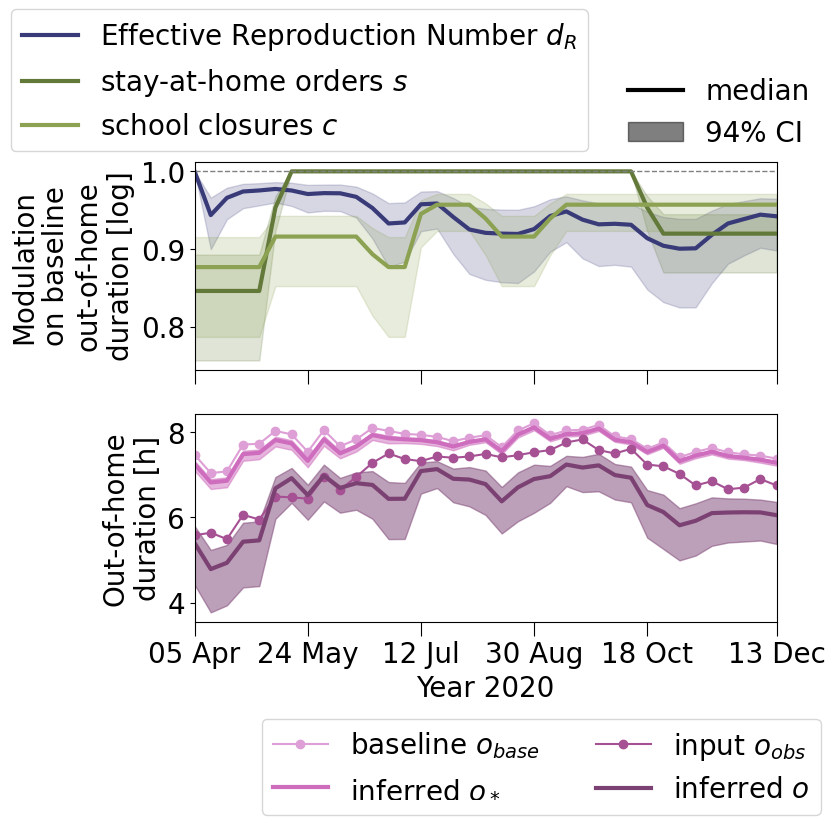

In [12]:
plot.analysis_figures(R_model, R_trace, tag, dates, indicators)

In [57]:
# load trace from file
tag = "R_test_p_linear"
indicators = ["R"]
R_trace_linear = load_trace(tag)

# load model
R_model_linear = load_model(indicators, {'R': R_data})

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [51]:
az.summary(R_trace,  
           round_to=2,
           #var_names=['p0', 'r']
           #var_names=['del_t', 'del_p', 'tau', 'z_R', 'mu_R', 'sigma_R', 'z_S', 'sigma_model']
           )

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_R,0.38,0.08,0.26,0.54,0.01,0.01,60.69,176.80,1.03
mu_R,0.90,0.31,0.43,1.47,0.02,0.01,359.68,351.26,1.00
delta_R,0.06,0.04,0.01,0.12,0.00,0.00,305.82,283.16,1.00
z_S,0.31,0.03,0.25,0.37,0.00,0.00,162.27,207.29,1.03
p0,1.19,0.07,1.08,1.32,0.01,0.01,57.98,165.24,1.04
...,...,...,...,...,...,...,...,...,...
m[32],7.03,0.08,6.88,7.19,0.00,0.00,382.73,265.20,1.00
m[33],7.00,0.08,6.85,7.14,0.00,0.00,413.84,308.00,1.00
m[34],6.99,0.08,6.87,7.15,0.00,0.00,428.30,307.15,1.00
m[35],6.97,0.08,6.85,7.13,0.00,0.00,402.66,308.28,1.00


Sampling: [p0]
INFO     [pymc] Sampling: [p0]


Directory  figures/R_test_p_linear  created.


Sampling: [p0, r]
INFO     [pymc] Sampling: [p0, r]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_R]
INFO     [pymc] Sampling: [z_R]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [delta_R, mu_R]
INFO     [pymc] Sampling: [delta_R, mu_R]
Sampling: [delta_R]
INFO     [pymc] Sampling: [delta_R]


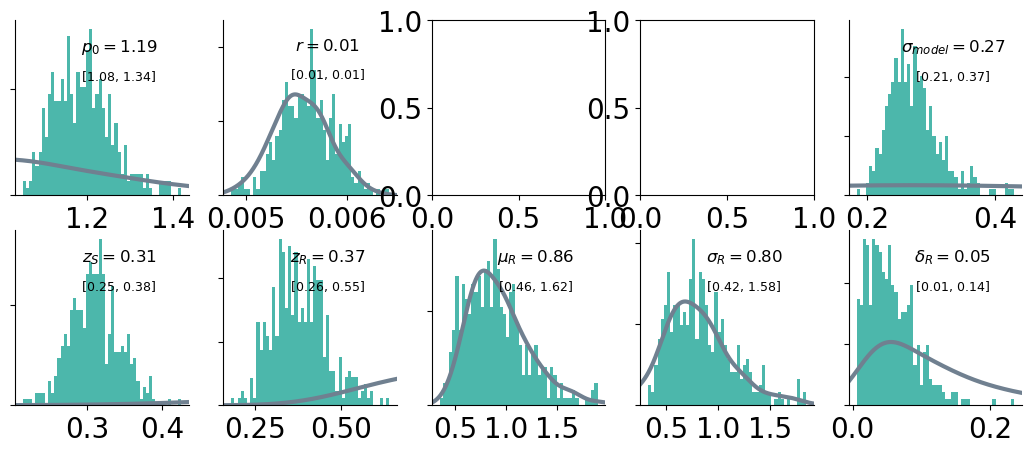

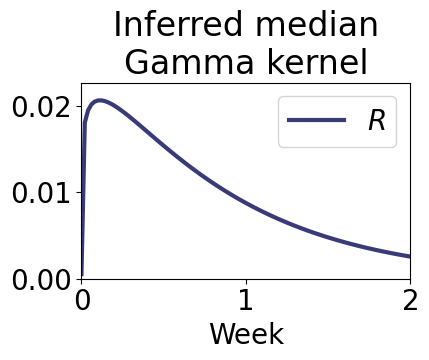

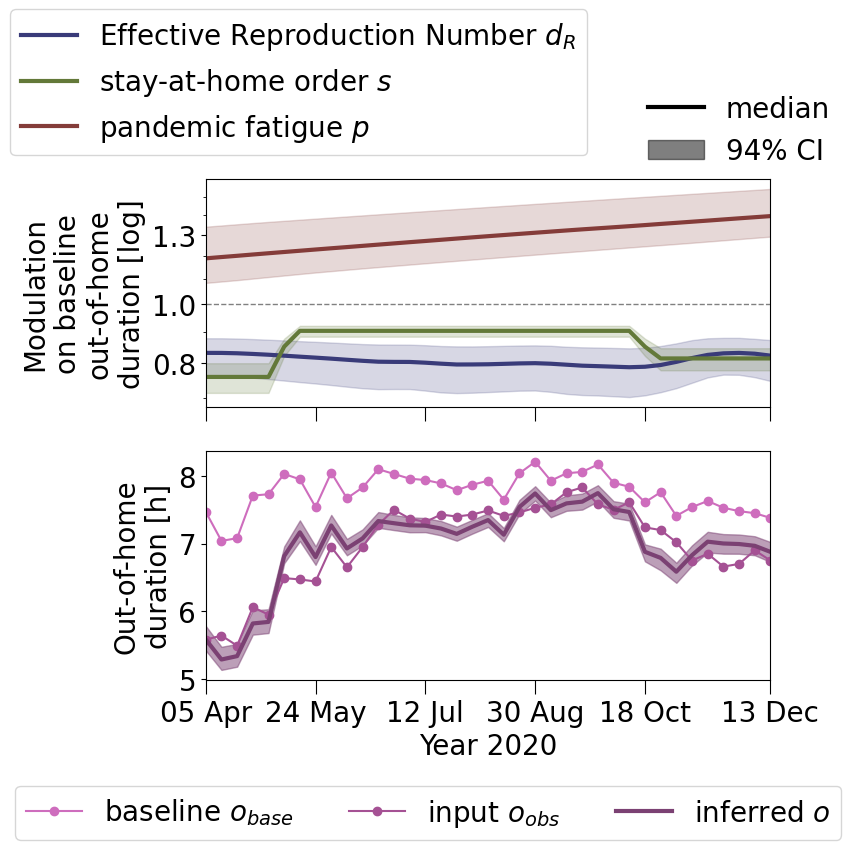

In [52]:
plot.analysis_figures(R_model, R_trace, tag, dates, indicators)

array([[<Axes: title={'center': 'z_R'}>, <Axes: title={'center': 'z_R'}>],
       [<Axes: title={'center': 'mu_R'}>,
        <Axes: title={'center': 'mu_R'}>],
       [<Axes: title={'center': 'sigma_R'}>,
        <Axes: title={'center': 'sigma_R'}>],
       [<Axes: title={'center': 'z_S'}>, <Axes: title={'center': 'z_S'}>],
       [<Axes: title={'center': 'c0'}>, <Axes: title={'center': 'c0'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'sigma_model'}>,
        <Axes: title={'center': 'sigma_model'}>],
       [<Axes: title={'center': 'd_R'}>, <Axes: title={'center': 'd_R'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'm'}>, <Axes: title={'center': 'm'}>]],
      dtype=object)

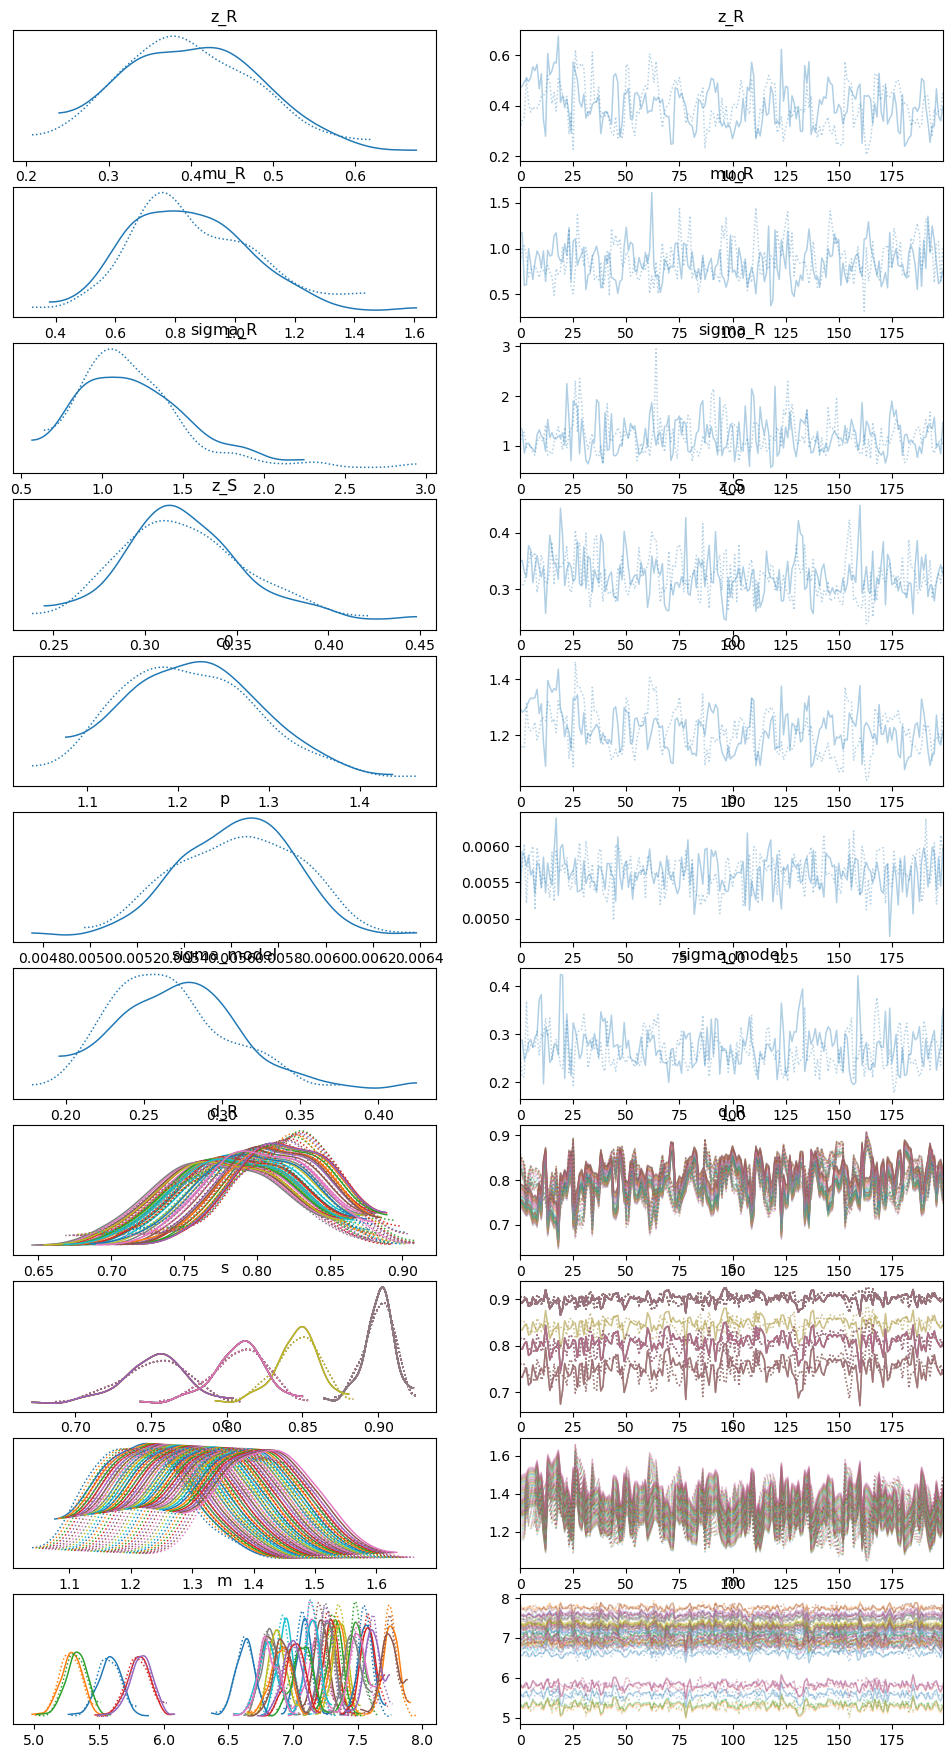

In [33]:
# plot chains
az.plot_trace(R_trace, compact=True)

## ICU

In [84]:
# load trace from file
tag = "ICU_model_full"
ICU_trace = load_trace(tag)
ICU_model = load_model(ICU_data)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [67]:
az.summary(ICU_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
offset,25.051,2.060,21.383,28.895,0.111,0.079,348.0,282.0,1.01
shift,-19.886,1.888,-23.688,-16.687,0.099,0.070,361.0,282.0,1.01
z,0.139,0.020,0.103,0.178,0.001,0.001,257.0,206.0,1.01
mu,1.746,0.502,0.875,2.689,0.034,0.024,220.0,240.0,1.01
sigma,0.867,0.232,0.403,1.226,0.014,0.010,254.0,257.0,1.02
...,...,...,...,...,...,...,...,...,...
m[32],6.413,0.111,6.207,6.596,0.006,0.005,293.0,335.0,1.01
m[33],6.224,0.111,6.027,6.403,0.006,0.004,334.0,258.0,1.00
m[34],6.112,0.107,5.922,6.303,0.006,0.004,341.0,272.0,1.00
m[35],6.048,0.107,5.858,6.241,0.006,0.004,341.0,315.0,1.00


Sampling: [z]
INFO     [pymc] Sampling: [z]


Sampling: [mu]
INFO     [pymc] Sampling: [mu]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma_model]
INFO     [pymc] Sampling: [sigma_model]
Sampling: [z_S]
INFO     [pymc] Sampling: [z_S]
Sampling: [z_T]
INFO     [pymc] Sampling: [z_T]
Sampling: [amplitude]
INFO     [pymc] Sampling: [amplitude]
Sampling: [offset]
INFO     [pymc] Sampling: [offset]
Sampling: [shift]
INFO     [pymc] Sampling: [shift]
Sampling: [a_r]
INFO     [pymc] Sampling: [a_r]


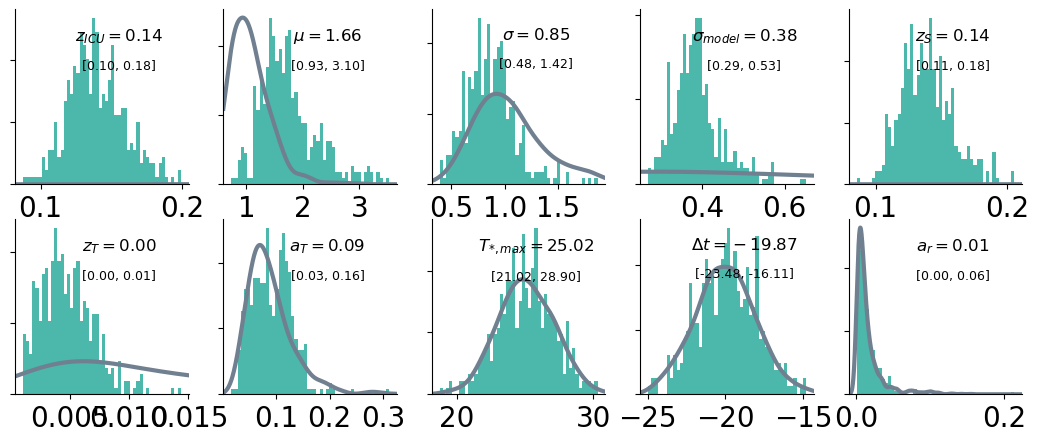

In [77]:
plot_distributions(ICU_model, ICU_trace, tag, 'z_{ICU}')

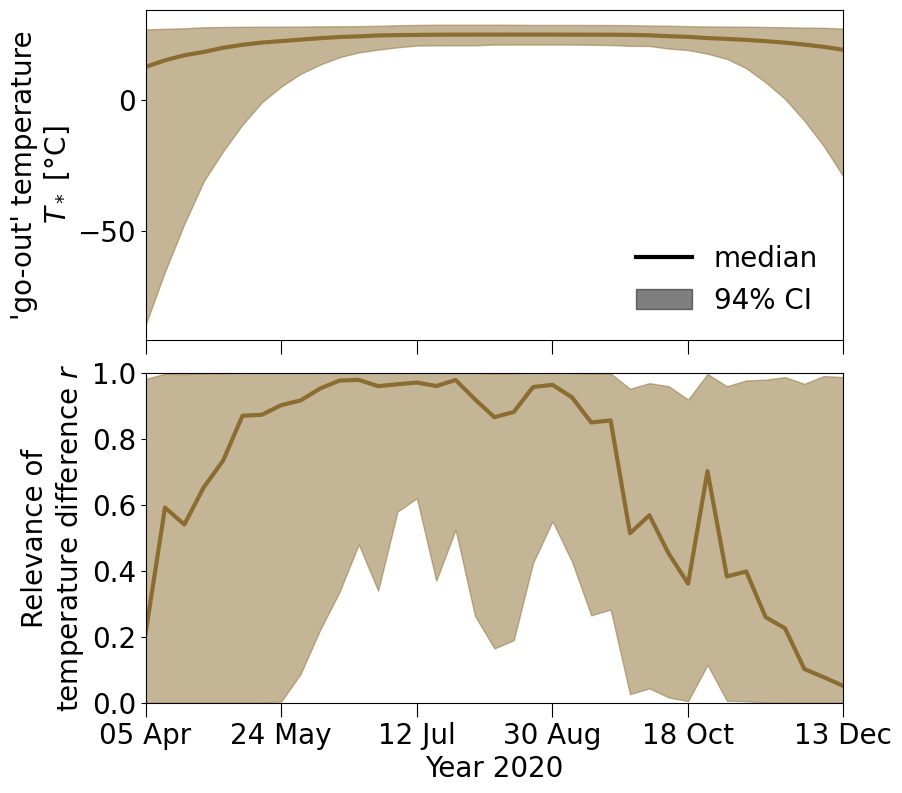

In [78]:
plot_temperature_timeseries(dates, ICU_trace, tag)

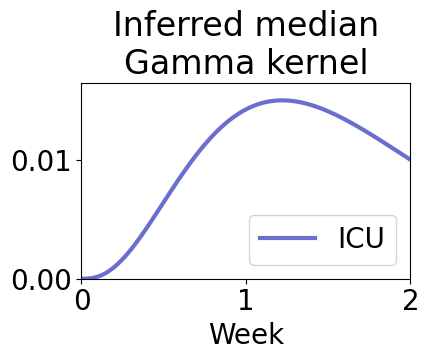

In [80]:
plot_gamma_kernel(ICU_trace, tag, {"mu": "mu", "sigma": "sigma", "label": "ICU", "color": color_ICU})

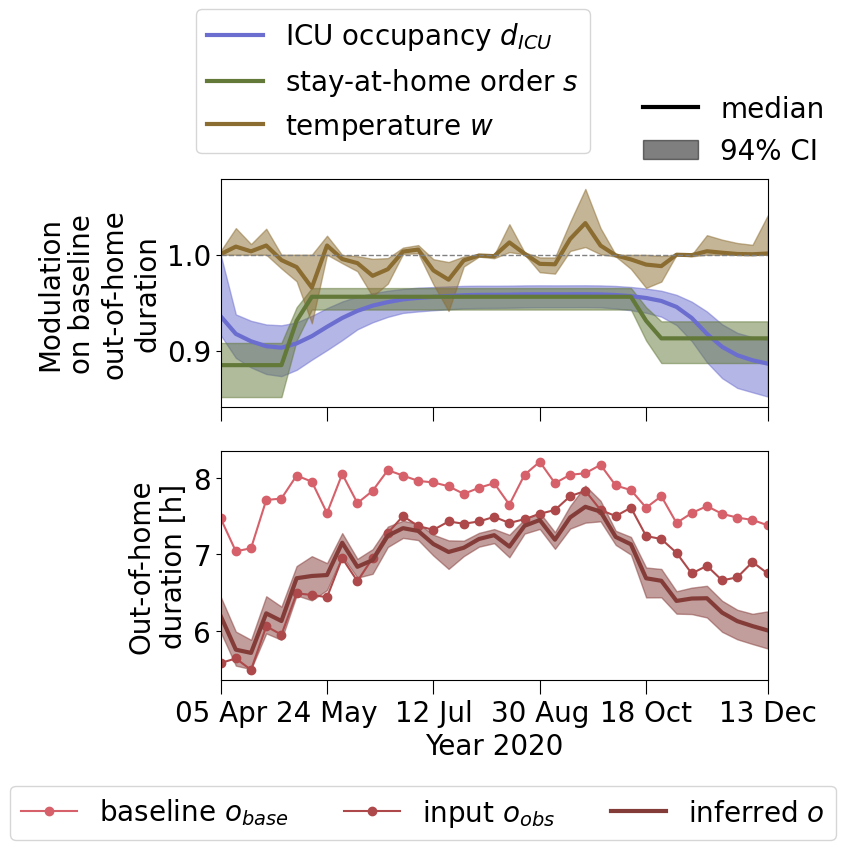

In [85]:
plot_out_of_home_duration_timeseries(
  dates,
  ICU_trace,
  tag,
  {
    "color": color_ICU,
    "del": "d",
    "del_label": "ICU occupancy $d_{ICU}$",
  },
)

# Comparison

## Pandemic fatigue

In [11]:
names = ["test_sigmoid", "test_linear"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for name in names:
    key_dict[name] = []
    for indicators in all_indicator_combinations:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        #indicator_tag = indicator_tag[:-1]
        key = name[5:] + ", " + key[:-1]
        key_dict[name].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

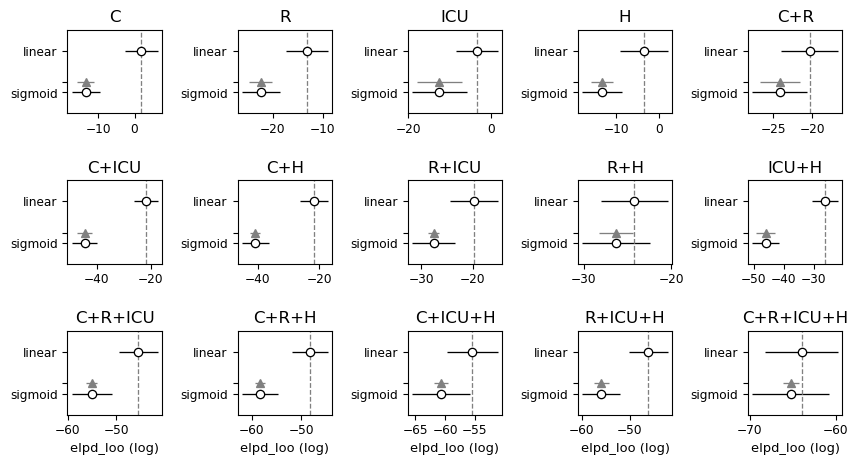

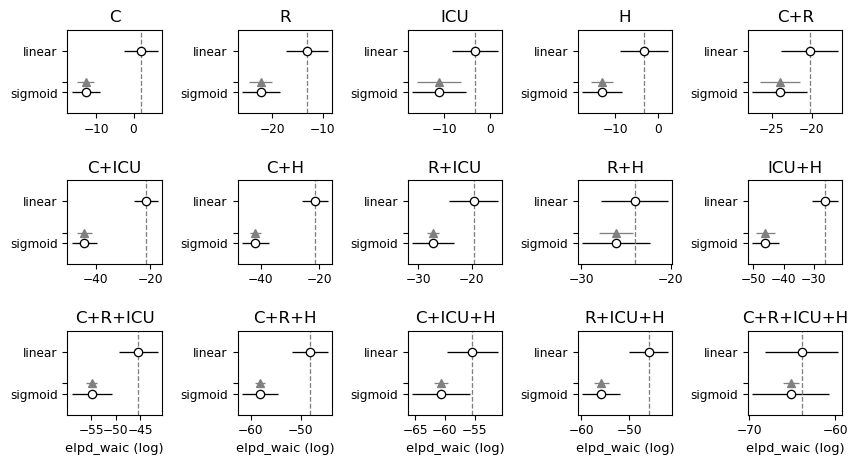

In [53]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
nrows = 3
ncols = 5
for ic in ['loo', 'waic']:
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 5))
    axs = axs.flatten()
    for i in range(len(all_indicator_combinations)):
        keys = [key_dict[name][i] for name in key_dict.keys()]
        # split key-string at ', '
        keys_separate = [key.split(', ') for key in keys]
        axs[i].set_title(keys_separate[0][1], fontsize=12)
        traces = {}
        for j in range(len(keys)):
            strings = keys_separate[j]
            key = keys[j]
            traces[strings[0]] = trace_dict[key]
        comparison = az.compare(traces, ic=ic)
        az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
        axs[i].set_ylabel('')
        if 15 - i > ncols:
            axs[i].set_xlabel('')
    # add horizontal padding between subplots
    fig.subplots_adjust(wspace=0.8, hspace=0.8)
    # save figure
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.png', bbox_inches='tight')
    fig.savefig(f'figures/model_selection/{ic}_pandemic_fatigue_pair.pdf', bbox_inches='tight')

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

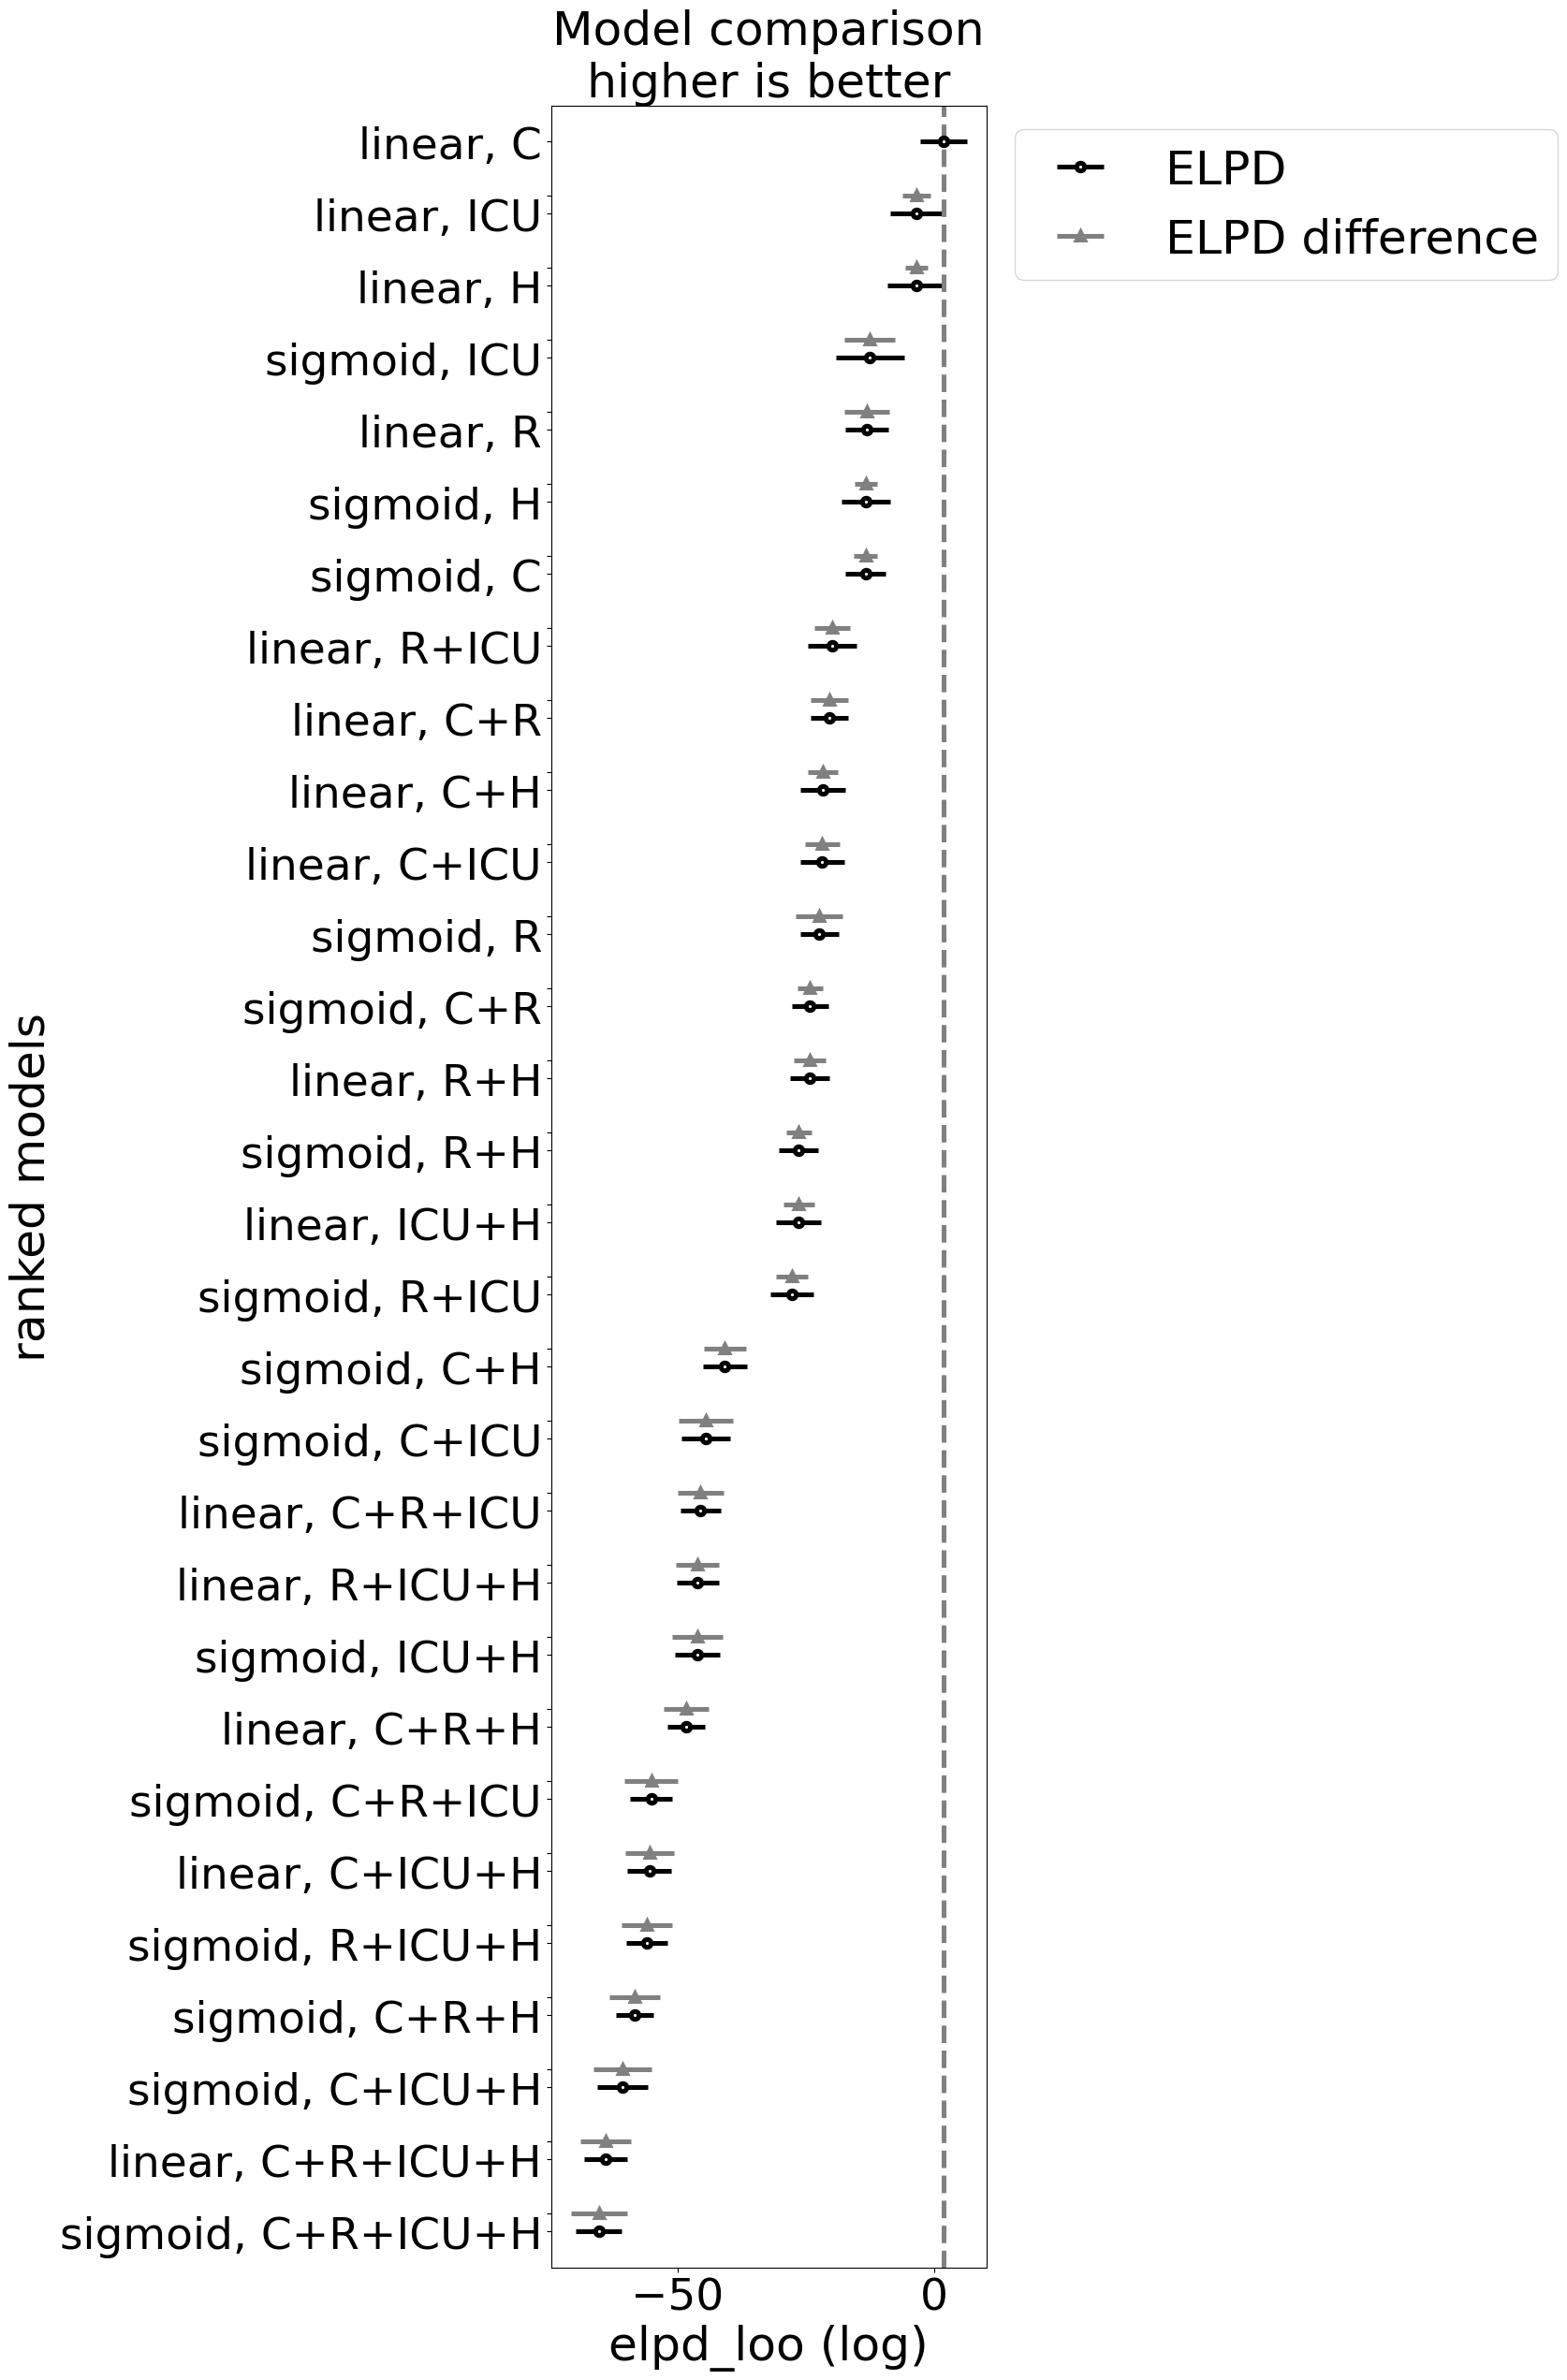

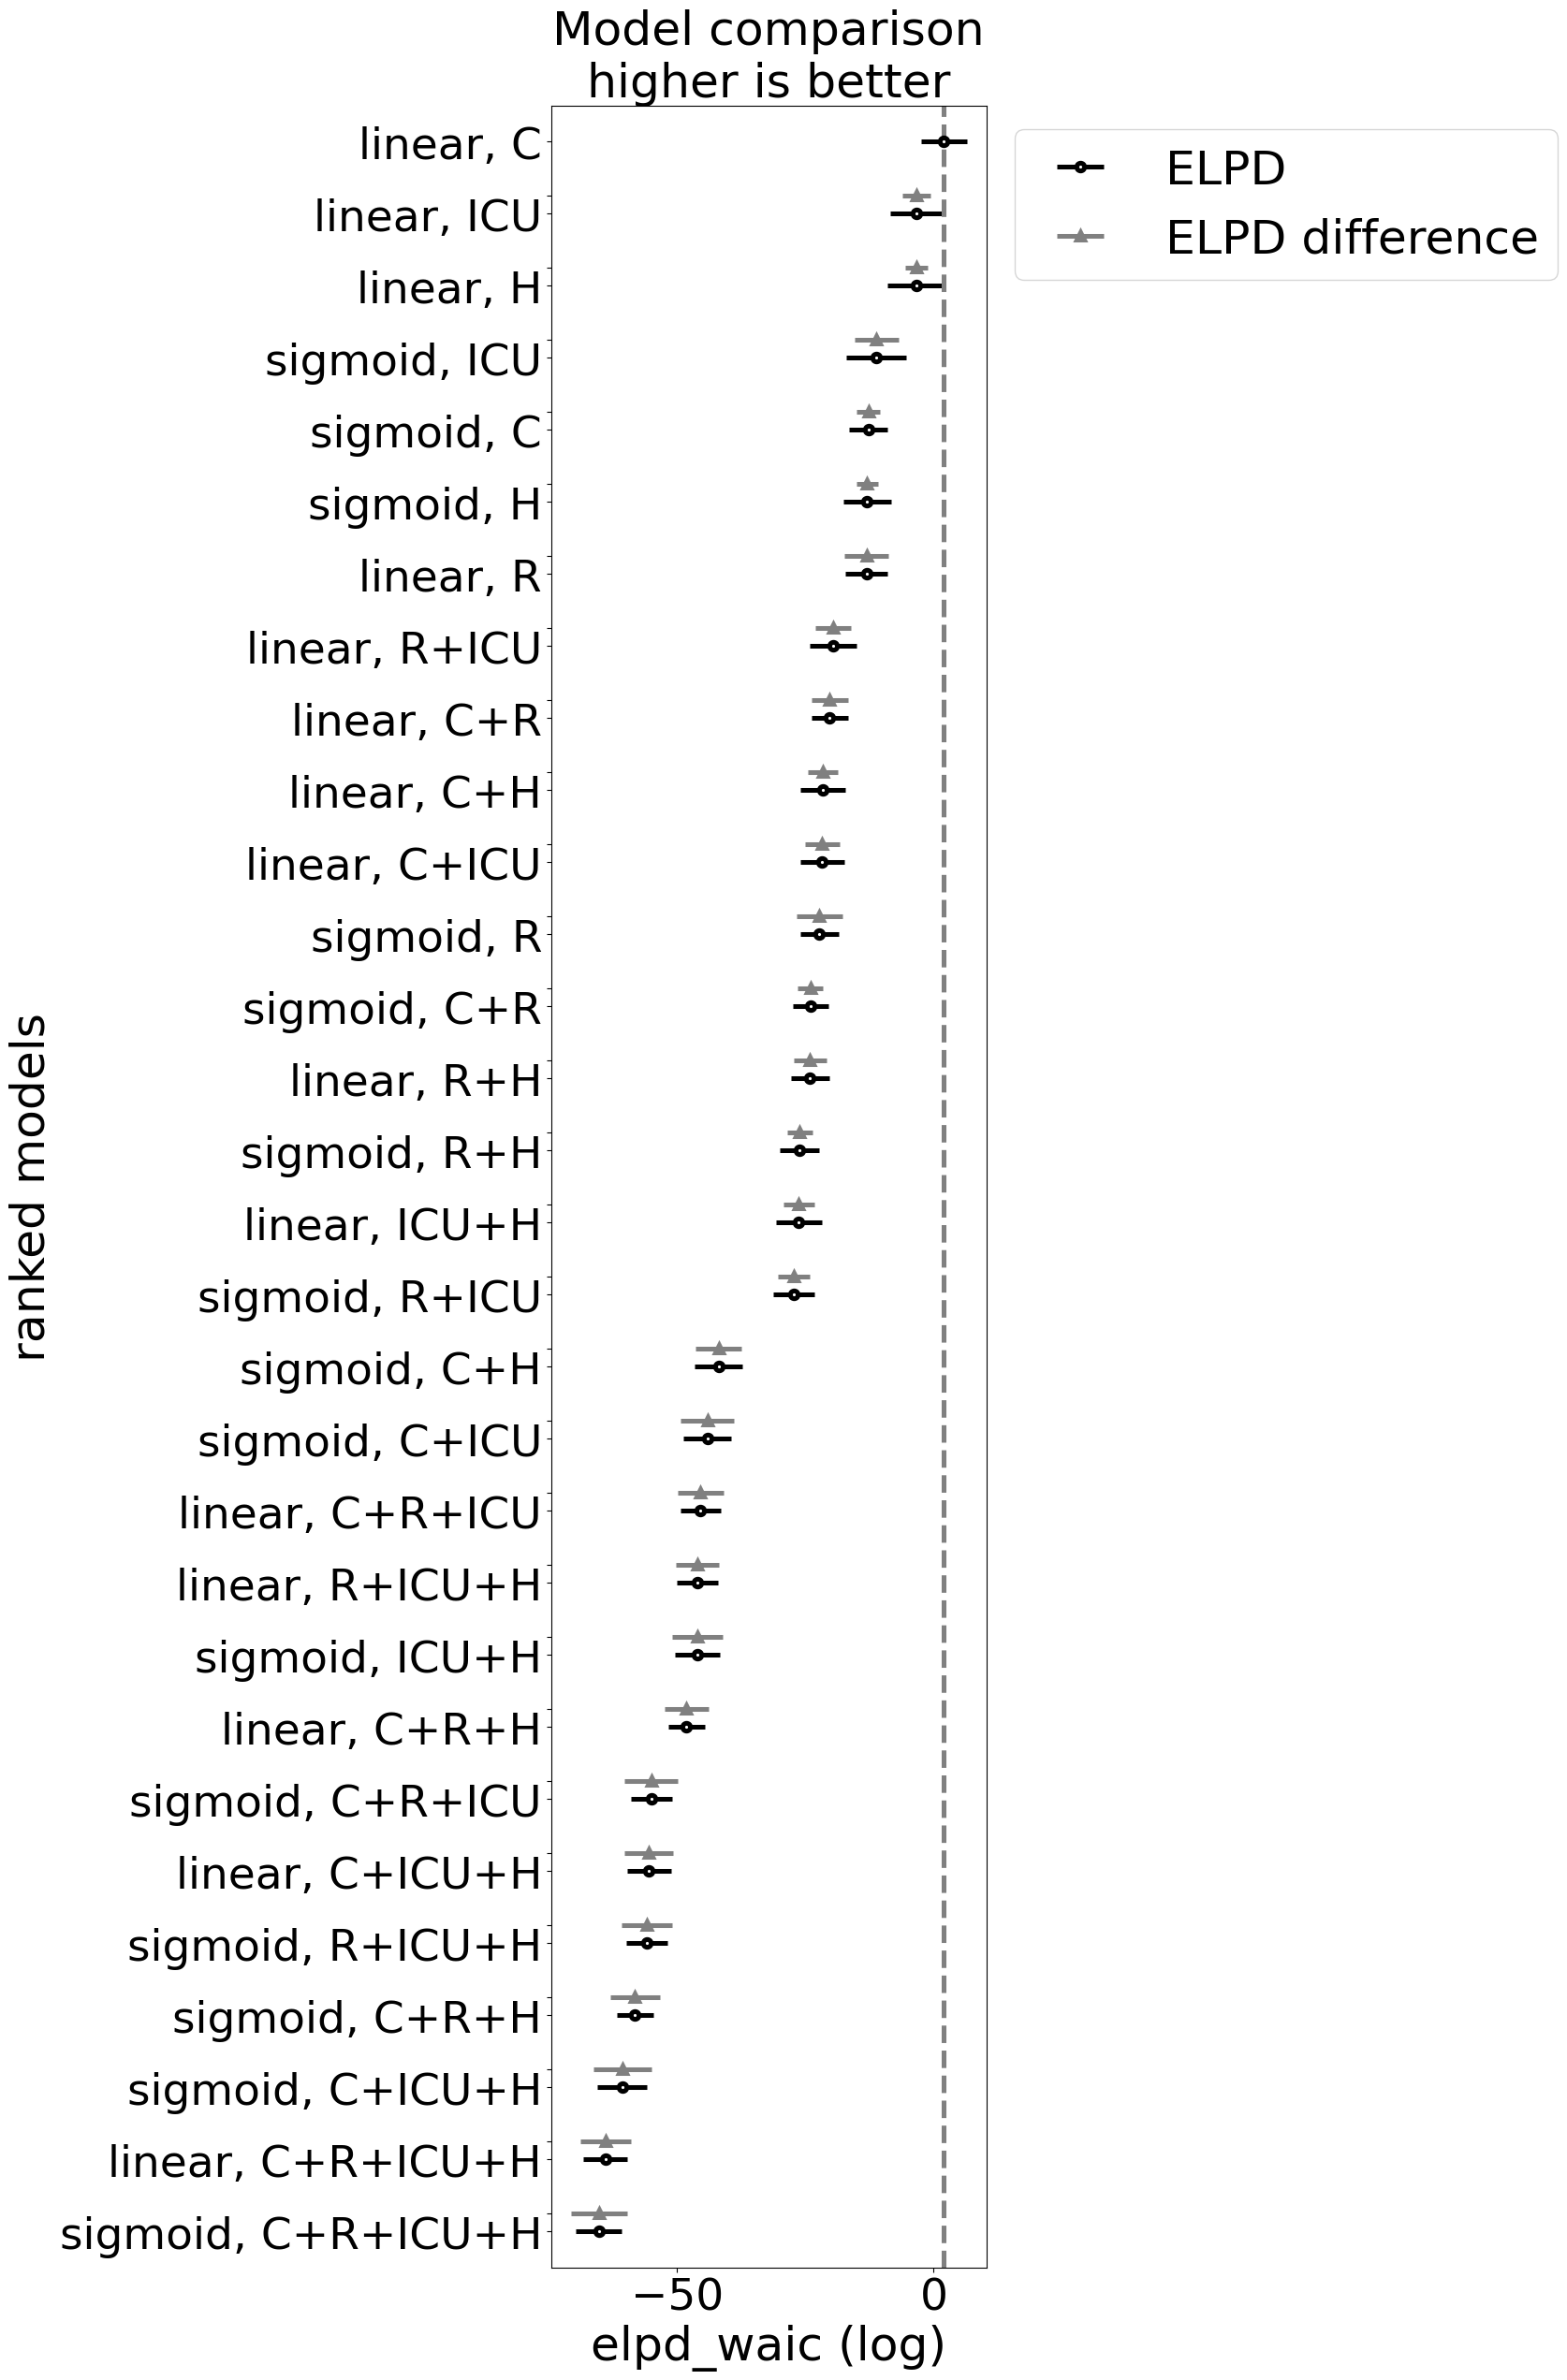

In [28]:
# model selection between all models in trace_dict
ics = ["loo", "waic"]
for ic in ics:
    comparison = az.compare(trace_dict, ic=ic)
    plot_result = az.plot_compare(comparison)
    # save plot
    plot_result.figure.savefig(f"figures/model_selection/{ic}_compare_pandemic_fatigue_all.png", bbox_inches="tight")

## Weather

In [10]:
names = [#"test_linear", 
         "precipitation", "temperature", "weather"]
labels = [#"no weather", 
          "precipitation", "temperature", "both"]
# create empty dictionary with all indicator combinations as keys
trace_dict = {}
key_dict = {}

# generate dictionary of all traces
for i in range(len(names)):
    name = names[i]
    label = labels[i]
    key_dict[label] = []
    for indicators in all_indicator_combinations:
        indicator_tag = ""
        key = ""
        for indicator in indicators:
            indicator_tag += indicator + "_"
            key += indicator + "+"
        indicator_tag = indicator_tag[:-1]
        key = label + ", " + key[:-1]
        key_dict[label].append(key)

        trace_dict[key] = utils.load_trace(name, indicator_tag)

/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/mambaforge/envs/mobility/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/data.nst/eiftekhar/

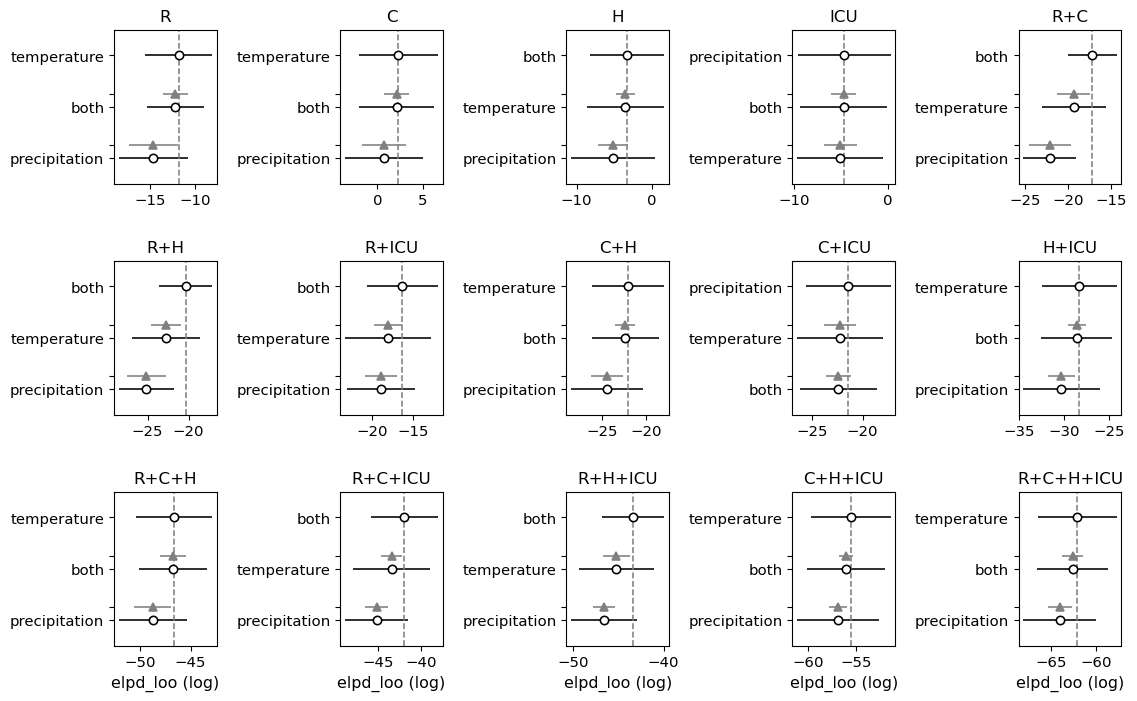

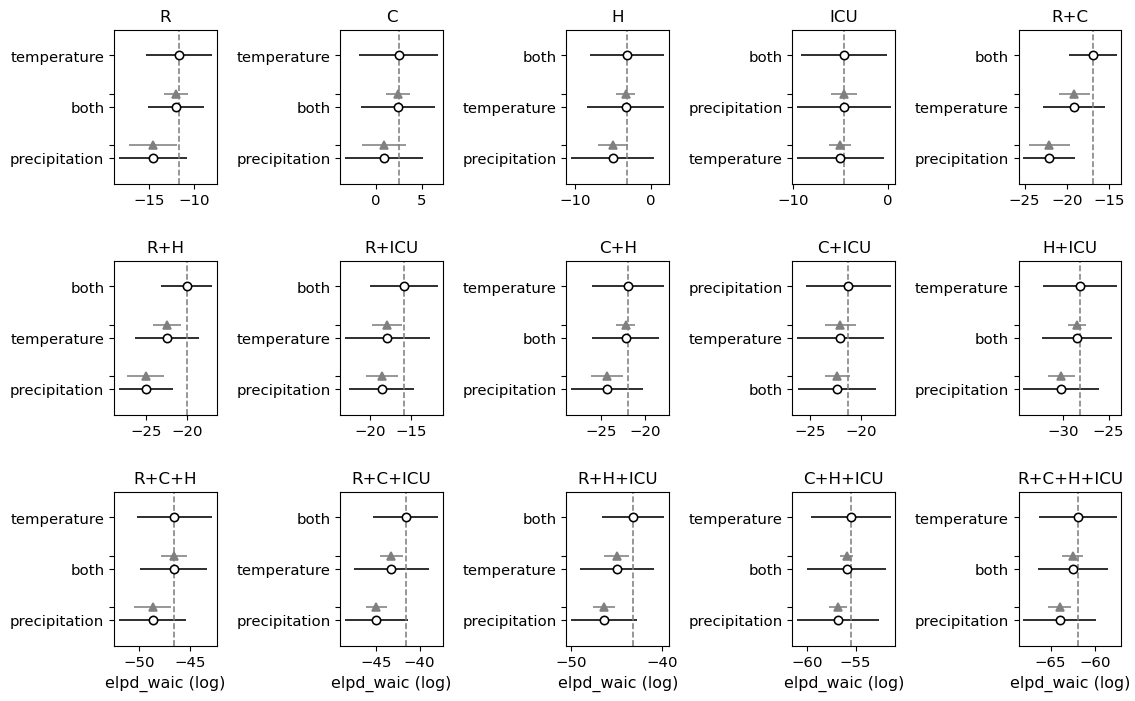

In [15]:
# compare plot with subplot for each indicator comibination, comparing the linear and sigmoid models
nrows = 3
ncols = 5
for ic in ['loo', 'waic']:
    fig, axs = plt.subplots(nrows, ncols, figsize=(13, 8))
    axs = axs.flatten()
    for i in range(len(all_indicator_combinations)):
        keys = [key_dict[name][i] for name in key_dict.keys()]
        # split key-string at ', '
        keys_separate = [key.split(', ') for key in keys]
        axs[i].set_title(keys_separate[0][1], fontsize=12)
        traces = {}
        for j in range(len(keys)):
            strings = keys_separate[j]
            key = keys[j]
            traces[strings[0]] = trace_dict[key]
        comparison = az.compare(traces, ic=ic)
        az.plot_compare(comparison, ax=axs[i], legend=False, title=False)
        axs[i].set_ylabel('')
        if 15 - i > ncols:
            axs[i].set_xlabel('')
    # add horizontal padding between subplots
    fig.subplots_adjust(wspace=1.2, hspace=0.5)
    # save figure
    fig.savefig(f'figures/model_selection/{ic}_weather.png', bbox_inches='tight')
    fig.savefig(f'figures/model_selection/{ic}_weather.pdf', bbox_inches='tight')